# TSLA 36-run sweep — analysis

Every number in `analyses/tsla_200days_report.html`, recomputed here from source so each
one can be checked and changed.

**Data.** `results.csv` (36 configurations) and `additions.csv` (360 proposed ontology
additions), both produced by `pull_and_analyze.py`, which pulls the runs from the MLflow
tracking server. Re-run that script to refresh; this notebook only reads the CSVs.

**Scope.** The 36 runs are the TSLA half of the balanced design, on the 200-day window
(2022-05-02 → 2022-11-18), all after the `36f4f88` path-embedding fix. Runs before that fix
had a silently empty path feature block and must not be pooled with these.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

runs = pd.read_csv("results.csv")
adds = pd.read_csv("additions.csv")

FACTORS = ["lookback_days", "steps", "chain_hops", "evolution_prompt"]
print(f"{len(runs)} configurations, {len(adds)} addition records")
runs.head(3)

36 configurations, 360 addition records


,run_id,lookback_days,steps,chain_hops,evolution_prompt,baseline_auc,final_auc,delta,final_candidate,path_mean_norm,brier_score,f1,n_nodes,n_edges,max_hops_val
0,fe10350f1eb54fef84a9ca753174ad31,3,3,3,default,0.521739,0.787185,0.265446,step_1_candidate_1,0.792126,0.199130,0.714286,3057,15520,3
1,798cdc6344ef4cadb84c6f9df09e6148,20,5,3,event_driven,0.649886,0.743707,0.093822,step_5_candidate_0,0.150222,0.209277,0.666667,4229,34790,3
2,47542f41c56a41139c2b1100bda8d3b9,10,3,5,event_driven,0.521739,0.729977,0.208238,step_2_candidate_0,0.000000,0.246173,0.680851,3179,19269,0


## A · What was run

Four hyperparameters varied at once. The full grid is 4 x 3 x 3 x 3 = 108 combinations;
36 were run — one third — chosen so that comparisons stay fair.

In [2]:
# Everything that was held fixed should have exactly one distinct value.
fixed = runs.nunique()
print("varying:", list(fixed[fixed > 1].index[fixed[fixed > 1].index.isin(FACTORS)]))
print()
for f in FACTORS:
    print(f"{f:18} {sorted(runs[f].unique(), key=str)}   n per level = {runs[f].value_counts().unique()}")

varying: ['lookback_days', 'steps', 'chain_hops', 'evolution_prompt']

lookback_days      [10, 20, 3, 8]   n per level = [9]
steps              [3, 5, 7]   n per level = [12]
chain_hops         [3, 4, 5]   n per level = [12]
evolution_prompt   ['default', 'event_driven', 'fundamental']   n per level = [12]


In [3]:
# Pairwise balance: for every PAIR of factors, does every level combination appear,
# and equally often? Counting observed combinations alone would hide a missing cell,
# so build the full grid and check for zeros explicitly.
from itertools import combinations

for a, b in combinations(FACTORS, 2):
    grid = pd.crosstab(runs[a], runs[b])
    counts = sorted(set(grid.values.ravel()))
    print(f"{a:17} x {b:18} cells={grid.size:>2}  missing={int((grid == 0).sum().sum())}  counts={counts}")

lookback_days     x steps              cells=12  missing=0  counts=[3]
lookback_days     x chain_hops         cells=12  missing=0  counts=[3]
lookback_days     x evolution_prompt   cells=12  missing=0  counts=[3]
steps             x chain_hops         cells= 9  missing=0  counts=[4]
steps             x evolution_prompt   cells= 9  missing=0  counts=[4]
chain_hops        x evolution_prompt   cells= 9  missing=0  counts=[4]


Every pair is complete and each combination appears an equal number of times (3 or 4,
depending on how many levels the two factors have). That is what lets us read a factor's
effect straight off its group means: comparing `steps=3` against `steps=7`, both groups
hold an identical mix of every other setting, so no adjustment is needed.

## B · Results

Each run ends at its **final accepted ontology**. `baseline_auc` is the article-text
baseline computed on the same days.

In [4]:
cols = ["final_auc", "baseline_auc", "delta"] + FACTORS + ["path_mean_norm"]
runs.sort_values("final_auc", ascending=False)[cols].head(10).reset_index(drop=True)

,final_auc,baseline_auc,delta,lookback_days,steps,chain_hops,evolution_prompt,path_mean_norm
0,0.787185,0.521739,0.265446,3,3,3,default,0.792126
1,0.743707,0.649886,0.093822,20,5,3,event_driven,0.150222
2,0.729977,0.521739,0.208238,10,3,5,event_driven,0.000000
3,0.723112,0.558352,0.164760,8,3,5,event_driven,0.000000
4,0.700229,0.521739,0.178490,10,7,5,default,0.000000
5,0.681922,0.649886,0.032037,20,7,5,default,0.000000
6,0.672769,0.649886,0.022883,20,7,3,fundamental,0.273820
7,0.668192,0.521739,0.146453,10,5,3,event_driven,0.230268
8,0.633867,0.558352,0.075515,8,7,5,default,0.122216
9,0.633867,0.649886,-0.016018,20,7,4,event_driven,0.384648


In [5]:
runs[["final_auc", "baseline_auc", "delta", "brier_score"]].describe().T[
    ["mean", "std", "50%", "min", "max"]
].round(4)

,mean,std,50%,min,max
final_auc,0.6168,0.0649,0.6098,0.4691,0.7872
baseline_auc,0.5629,0.0531,0.5400,0.5217,0.6499
delta,0.0538,0.0844,0.0606,-0.1259,0.2654
brier_score,0.2931,0.0407,0.2903,0.1991,0.3885


In [6]:
beat = (runs.delta > 0).sum()
lost = (runs.delta < 0).sum()
print(f"beat the text baseline: {beat}   fell below it: {lost}   tied: {(runs.delta == 0).sum()}")
print(f"mean difference {runs.delta.mean():+.4f}   range {runs.delta.min():+.4f} to {runs.delta.max():+.4f}")

beat the text baseline: 28   fell below it: 8   tied: 0
mean difference +0.0538   range -0.1259 to +0.2654


### The two arms share no features

`build_day_feature_vector` skips article text entirely ("using structural signals only"),
so the evolved arm is path (384) + subgraph (96) + topology (8) = **488 structural
dimensions with no text**, while the baseline is mean-pooled article embeddings with no
graph. `delta` is therefore a contrast between two disjoint representations, not an
ablation of the ontology. No configuration in this sweep tested *text + graph* against
*text*, so nothing here shows the knowledge graph adding to what the article text already
carries.

One consequence worth checking directly: because the baseline pools articles over the same
lookback window as the graph arm, `lookback_days` moves **both** arms.

In [7]:
by_lb = runs.groupby("lookback_days").agg(
    n=("final_auc", "size"),
    distinct_baselines=("baseline_auc", "nunique"),
    baseline=("baseline_auc", "first"),
    final_auc=("final_auc", "mean"),
    delta=("delta", "mean"),
    beat=("delta", lambda s: (s > 0).sum()),
).sort_values("delta", ascending=False)
by_lb.round(4)

,n,distinct_baselines,baseline,final_auc,delta,beat
lookback_days,,,,,,
10,9,1,0.5217,0.6428,0.1210,9
3,9,1,0.5217,0.6064,0.0847,9
8,9,1,0.5584,0.5967,0.0384,7
20,9,1,0.6499,0.6212,-0.0287,3


One distinct baseline per lookback level, identical across all 9 runs at that level — so
the baseline is fully deterministic, and the variation is the lookback factor rather than
noise. It also means lookback is the only factor where ranking by absolute AUC and ranking
by improvement-over-text disagree: `lookback=20` is second by final AUC but last by delta,
and loses 6 of its 9 head-to-heads.

## C · Do path-chain features help?

`path_mean_norm` is the average Euclidean length of each day's 384-dimension path vector:
0 means the block is entirely zeros, ~0.79 means most days carry real chain embeddings.
Treating it as a continuous measure of realised path signal avoids the confound in a
hop-level comparison, where deep-hop runs are path-sparse *because* long chains are
unreachable at this graph density.

Spearman rho = -0.008 (p = 0.96)    OLS slope = -0.006


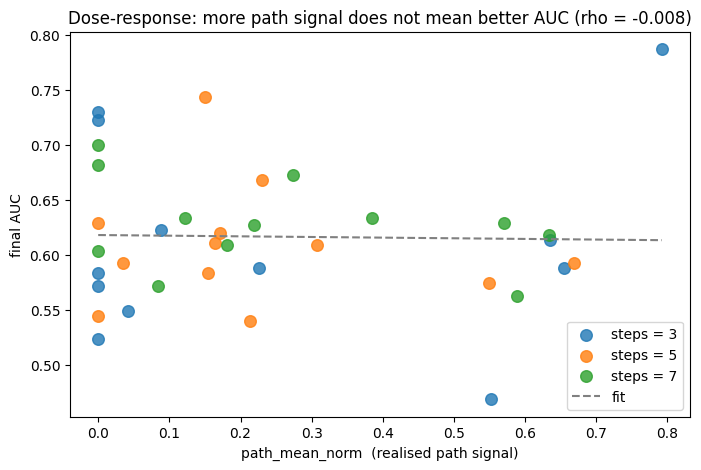

In [8]:
rho, p = stats.spearmanr(runs.path_mean_norm, runs.final_auc)
slope = np.polyfit(runs.path_mean_norm, runs.final_auc, 1)[0]
print(f"Spearman rho = {rho:+.3f} (p = {p:.2f})    OLS slope = {slope:+.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
for s, grp in runs.groupby("steps"):
    ax.scatter(grp.path_mean_norm, grp.final_auc, s=70, alpha=0.8, label=f"steps = {s}")
xs = np.linspace(0, runs.path_mean_norm.max(), 50)
ax.plot(xs, np.polyval(np.polyfit(runs.path_mean_norm, runs.final_auc, 1), xs),
        color="grey", ls="--", label="fit")
ax.set_xlabel("path_mean_norm  (realised path signal)")
ax.set_ylabel("final AUC")
ax.set_title(f"Dose-response: more path signal does not mean better AUC (rho = {rho:+.3f})")
ax.legend()
plt.show()

In [9]:
# How often is the path block empty at all, and does hop depth determine it?
runs.assign(empty=runs.path_mean_norm == 0).groupby("chain_hops").agg(
    n=("final_auc", "size"),
    empty_path_blocks=("empty", "sum"),
    mean_path_signal=("path_mean_norm", "mean"),
    mean_auc=("final_auc", "mean"),
).round(4)

,n,empty_path_blocks,mean_path_signal,mean_auc
chain_hops,,,,
3,12,0,0.5248,0.6266
4,12,3,0.1521,0.5885
5,12,7,0.0472,0.6352


Hop depth shifts the *probability* of an empty block rather than determining it. Path
signal falls by an order of magnitude across hop levels while AUC does not follow.

## D · Differential analysis by factor

In [10]:
grand, sd = runs.final_auc.mean(), runs.final_auc.std()
print(f"grand mean {grand:.4f}   between-run SD {sd:.4f}")

tbl = []
for f in FACTORS:
    g = runs.groupby(f).final_auc.agg(["size", "mean", "std"])
    for level, row in g.sort_values("mean", ascending=False).iterrows():
        tbl.append({"factor": f, "level": level, "n": int(row["size"]),
                    "mean_auc": row["mean"], "sd": row["std"],
                    "dev_from_grand": row["mean"] - grand,
                    "in_SD_units": abs(row["mean"] - grand) / sd})
tbl = pd.DataFrame(tbl)
tbl.round(4)

grand mean 0.6168   between-run SD 0.0649


,factor,level,n,mean_auc,sd,dev_from_grand,in_SD_units
0,lookback_days,10,9,0.6428,0.0468,0.0260,0.4006
1,lookback_days,20,9,0.6212,0.0711,0.0044,0.0676
2,lookback_days,3,9,0.6064,0.0719,-0.0104,0.1596
3,lookback_days,8,9,0.5967,0.0683,-0.0200,0.3085
4,steps,7,12,0.6287,0.0411,0.0120,0.1841
5,steps,3,12,0.6125,0.0918,-0.0043,0.0656
6,steps,5,12,0.6091,0.0552,-0.0077,0.1185
7,chain_hops,5,12,0.6352,0.0592,0.0184,0.2840
8,chain_hops,3,12,0.6266,0.0841,0.0099,0.1518
9,chain_hops,4,12,0.5885,0.0384,-0.0283,0.4358


largest separation from the grand mean: 0.44 SD (chain_hops = 4)


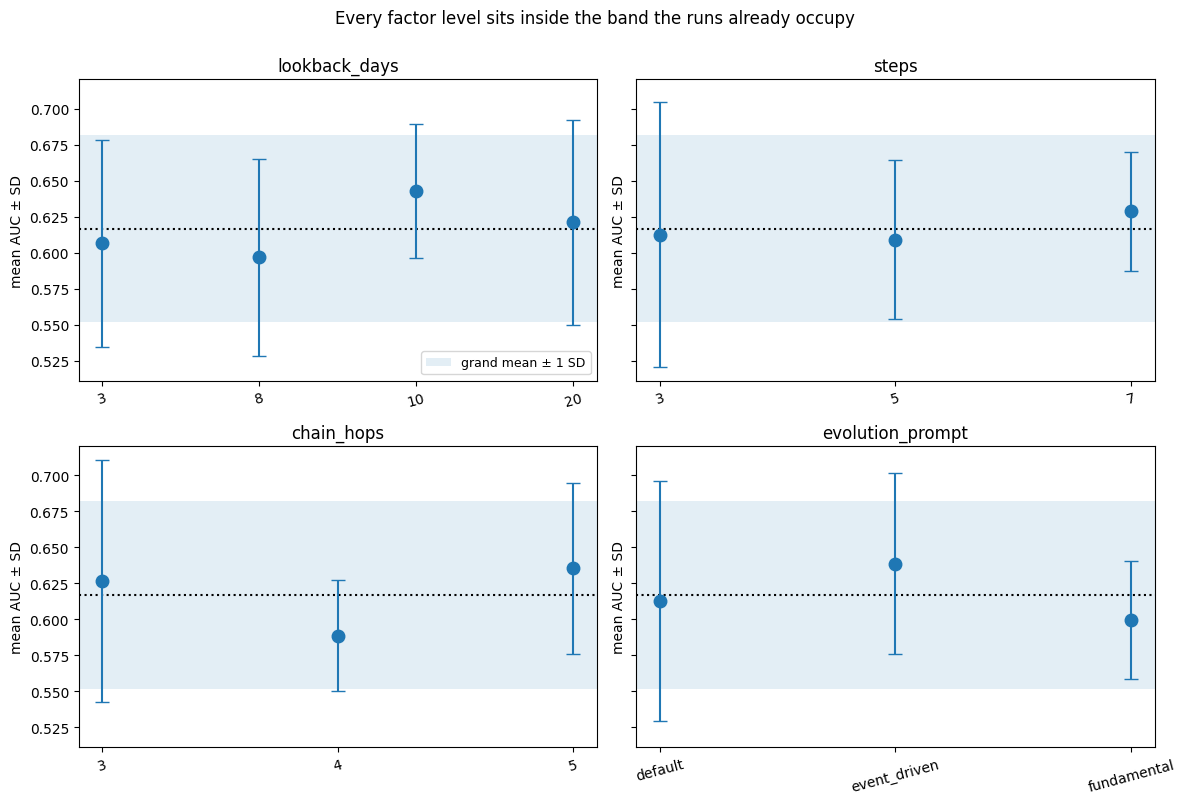

In [11]:
print(f"largest separation from the grand mean: {tbl.in_SD_units.max():.2f} SD "
      f"({tbl.loc[tbl.in_SD_units.idxmax(), 'factor']} = "
      f"{tbl.loc[tbl.in_SD_units.idxmax(), 'level']})")

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, f in zip(axes.flat, FACTORS):
    g = runs.groupby(f).final_auc.agg(["mean", "std"])
    x = range(len(g))
    ax.axhspan(grand - sd, grand + sd, alpha=0.12, label="grand mean ± 1 SD")
    ax.axhline(grand, ls=":", color="black")
    ax.errorbar(x, g["mean"], yerr=g["std"], fmt="o", capsize=5, markersize=9)
    ax.set_xticks(list(x))
    ax.set_xticklabels(g.index, rotation=15)
    ax.set_title(f)
    ax.set_ylabel("mean AUC ± SD")
axes.flat[0].legend(loc="lower right", fontsize=9)
fig.suptitle("Every factor level sits inside the band the runs already occupy", y=1.0)
fig.tight_layout()
plt.show()

In [12]:
# How much of the run-to-run variation do the factors actually explain? The design is
# balanced, so effects are additive and the fitted value is just the sum of level effects.
effects = {f: runs.groupby(f).final_auc.mean() - grand for f in FACTORS}
fitted = grand + sum(runs[f].map(effects[f]) for f in FACTORS)
resid = runs.final_auc - fitted

print(f"variance of final AUC   {runs.final_auc.var():.5f}")
print(f"residual variance       {resid.var():.5f}")
print(f"explained by 4 factors  {100 * (1 - resid.var() / runs.final_auc.var()):.1f}%")
print()
for f in FACTORS:
    ss = (runs.groupby(f).final_auc.agg(["size", "mean"])
          .pipe(lambda g: (g["size"] * (g["mean"] - grand) ** 2).sum()))
    print(f"  {f:18} {100 * ss / (runs.final_auc.var() * (len(runs) - 1)):.1f}%")

variance of final AUC   0.00421
residual variance       0.00313
explained by 4 factors  25.6%

  lookback_days      7.3%
  steps              1.8%
  chain_hops         10.1%
  evolution_prompt   6.4%


Roughly three quarters of why one run beats another has nothing to do with any
hyperparameter. Note `steps` is the weakest of the four, which is the sweep's core claim
about evolution depth.

## E · Ontology-change analysis

Each candidate proposes **one node type and one relationship together**, so the pair is the
unit of intervention — not the node.

In [13]:
print(f"node types: {adds.node.nunique()}   distinct (node, relationship) pairs: "
      f"{adds.groupby(['node', 'relationship']).ngroups}")
multi = adds.groupby("node").relationship.nunique()
print(f"node types proposed with more than one relationship: {(multi > 1).sum()}")
adds[adds.node == "RegulatoryBody"].relationship.value_counts()

node types: 32   distinct (node, relationship) pairs: 80
node types proposed with more than one relationship: 17


relationship
MENTIONS_REGULATORY_BODY    27
ISSUED_BY                    8
MENTIONS_REGULATORY          3
Name: count, dtype: int64

### Why not score against the run's current best

The acceptance gate makes the reference the *maximum AUC seen so far*, and a maximum only
ratchets upward. So a candidate's score mostly reflects how lucky step 1 was in its run.
The cell below shows it directly: mean candidate AUC is flat across steps while the
reference climbs, and the share scoring "negative" grows from 62% to around 90%.

,n,mean_candidate_auc,mean_reference,mean_scored_delta,pct_negative
step,,,,,
1,72,0.519,0.563,-0.044,62.500
2,72,0.504,0.576,-0.072,80.556
3,72,0.481,0.601,-0.120,93.056
4,48,0.485,0.599,-0.114,87.500
5,48,0.496,0.605,-0.109,91.667
6,24,0.497,0.609,-0.112,83.333
7,24,0.507,0.626,-0.119,87.500


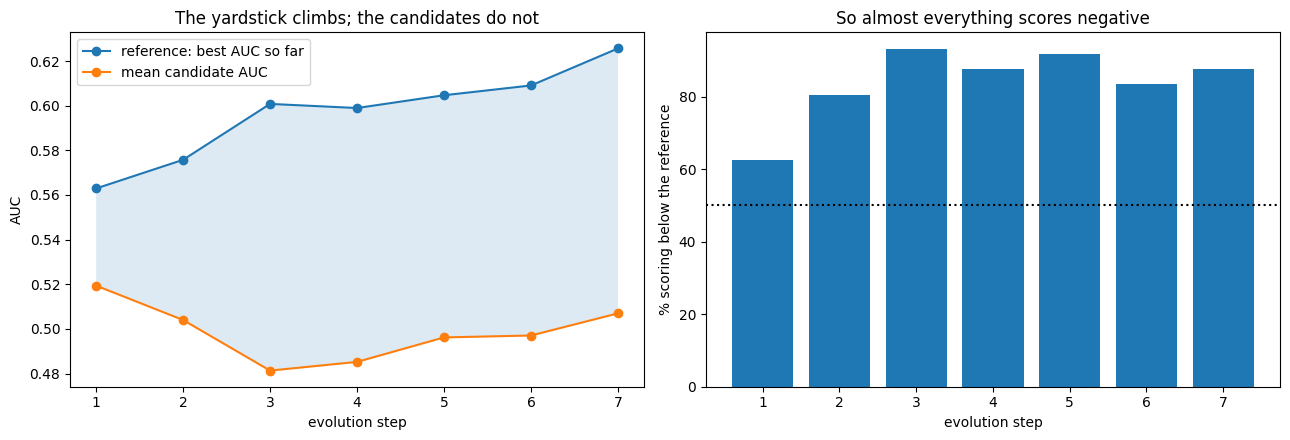

In [14]:
adds["reference"] = adds.auc - adds.delta_auc
bias = adds.groupby("step").agg(
    n=("auc", "size"),
    mean_candidate_auc=("auc", "mean"),
    mean_reference=("reference", "mean"),
    mean_scored_delta=("delta_auc", "mean"),
    pct_negative=("delta_auc", lambda s: 100 * (s < 0).mean()),
)
display(bias.round(3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(bias.index, bias.mean_reference, "o-", label="reference: best AUC so far")
ax1.plot(bias.index, bias.mean_candidate_auc, "o-", label="mean candidate AUC")
ax1.fill_between(bias.index, bias.mean_candidate_auc, bias.mean_reference, alpha=0.15)
ax1.set_xlabel("evolution step"); ax1.set_ylabel("AUC"); ax1.legend()
ax1.set_title("The yardstick climbs; the candidates do not")
ax2.bar(bias.index, bias.pct_negative)
ax2.axhline(50, ls=":", color="black")
ax2.set_xlabel("evolution step"); ax2.set_ylabel("% scoring below the reference")
ax2.set_title("So almost everything scores negative")
fig.tight_layout(); plt.show()

In [15]:
adds["is_step1"] = adds.step == 1
adds.groupby(adds.is_step1.map({True: "step 1 (ref = text baseline)",
                                False: "steps 2+ (ref = best so far)"})).agg(
    n=("delta_auc", "size"),
    mean_delta=("delta_auc", "mean"),
    pct_negative=("delta_auc", lambda s: 100 * (s < 0).mean()),
).round(3)

,n,mean_delta,pct_negative
is_step1,,,
step 1 (ref = text baseline),72,-0.044,62.5
steps 2+ (ref = best so far),288,-0.104,87.5


Within a single step, though, both candidates are built on the **same** graph and scored on
the same days. Comparing them to each other carries no reference bias at all.

In [16]:
# Within a step, the higher AUC wins. At 42 validation days the size of the gap is not
# worth reading -- only which one won.
top = adds.groupby(["run_id", "step"]).auc.transform("max")
n_at_top = adds.groupby(["run_id", "step"]).auc.transform(lambda s: (s == s.max()).sum())
adds["won"] = (adds.auc == top) & (n_at_top == 1)

pairs = (adds.groupby(["node", "relationship"])
         .won.agg(proposed="size", won="sum", win_rate="mean")
         .assign(win_rate=lambda d: 100 * d.win_rate)
         .query("proposed >= 8").sort_values("win_rate", ascending=False))
pairs.round(0)

proposed  won  \
node                   relationship                                      
RegulatoryBody         MENTIONS_REGULATORY_BODY                27   21   
                       ISSUED_BY                                8    6   
Product                MENTIONS_PRODUCT                        11    8   
MarketEvent            TRIGGERS                                10    6   
CreditRating           HAS_CREDIT_RATING                       35   19   
Executive              MENTIONS_EXECUTIVE                      12    6   
MarketIndex            MENTIONS_MARKET_INDEX                   12    6   
RegulatoryAnnouncement MENTIONS_REGULATORY_ANNOUNCEMENT         8    4   
LegalAction            INVOLVES_LEGAL_ACTION                    9    4   
GeographicRegion       LOCATED_IN                              25   11   
Industry               OPERATES_IN                             17    6   
EarningsReport         HAS_EARNINGS_REPORT                     12    4   
EconomicIndicator      REFERENCES                              36    8   

                                                         win_rate  
node                   relationship                                
RegulatoryBody         MENTIONS_REGULATORY_BODY              78.0  
                       ISSUED_BY                             75.0  
Product                MENTIONS_PRODUCT                      73.0  
MarketEvent            TRIGGERS                              60.0  
CreditRating           HAS_CREDIT_RATING                     54.0  
Executive              MENTIONS_EXECUTIVE                    50.0  
MarketIndex            MENTIONS_MARKET_INDEX                 50.0  
RegulatoryAnnouncement MENTIONS_REGULATORY_ANNOUNCEMENT      50.0  
LegalAction            INVOLVES_LEGAL_ACTION                 44.0  
GeographicRegion       LOCATED_IN                            44.0  
Industry               OPERATES_IN                           35.0  
EarningsReport         HAS_EARNINGS_REPORT                   33.0  
EconomicIndicator      REFERENCES                            22.0

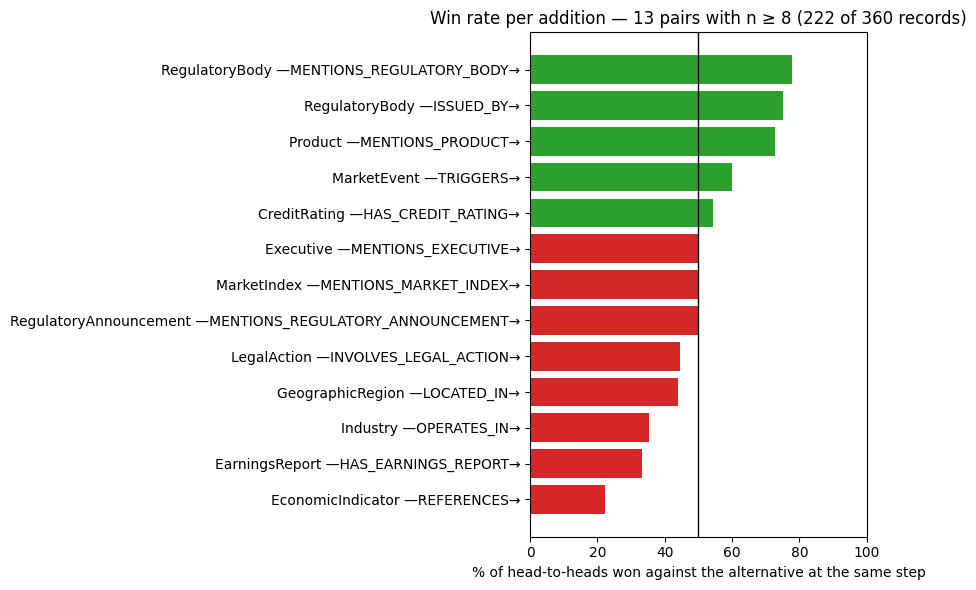

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
labels = [f"{n} —{r}→" for n, r in pairs.index]
ax.barh(labels, pairs.win_rate,
        color=["tab:green" if v > 50 else "tab:red" for v in pairs.win_rate])
ax.axvline(50, color="black", lw=1)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% of head-to-heads won against the alternative at the same step")
ax.set_title(f"Win rate per addition — {len(pairs)} pairs with n ≥ 8 "
             f"({int(pairs.proposed.sum())} of {len(adds)} records)")
fig.tight_layout()
plt.show()

The measure is zero-sum by construction: it ranks additions against each other and says
nothing about whether additions help in absolute terms.

In [18]:
adds.groupby("step").agg(
    proposed=("status", "size"),
    accepted=("status", lambda s: (s == "accepted").sum()),
    accept_rate=("status", lambda s: 100 * (s == "accepted").mean()),
).round(1)

,proposed,accepted,accept_rate
step,,,
1,72,36,50.0
2,72,11,15.3
3,72,4,5.6
4,48,5,10.4
5,48,4,8.3
6,24,3,12.5
7,24,3,12.5


Half of first-step candidates are accepted, then 6–15% from step 2 onward — the ontology
saturates early. Step 1's rate is not a quality signal: `_should_accept_step` returns `True`
whenever there is no previously accepted step, so step 1 is accepted unconditionally in
every run.

## What is not measured

- **An addition's absolute effect**, which would be AUC(base + addition) − AUC(base). The
  base structural graph is never scored — step 0 evaluates only the article-text baseline.
- **Whether the graph adds to text**, which needs a text + graph arm (see section B).
- **Training AUC**, so the train/validation gap is unknown. With 488 features against 98
  training days, that gap is the diagnostic this design most needs.
- **Replication variance** — all 36 configurations are distinct, so no two runs share
  settings and run-to-run noise was never observed directly.